
image 1/1 /content/sample_data/istockphoto-478525372-612x612.jpg: 448x640 1 person, 4 cars, 1 truck, 1 handbag, 365.7ms
Speed: 14.3ms preprocess, 365.7ms inference, 52.4ms postprocess per image at shape (1, 3, 448, 640)
person: 0.92 at [348, 125, 451, 324]
truck: 0.88 at [172, 52, 355, 225]
car: 0.84 at [47, 139, 185, 235]
car: 0.72 at [0, 147, 24, 213]
car: 0.69 at [525, 137, 566, 157]
car: 0.58 at [6, 136, 71, 197]
handbag: 0.58 at [400, 209, 431, 260]


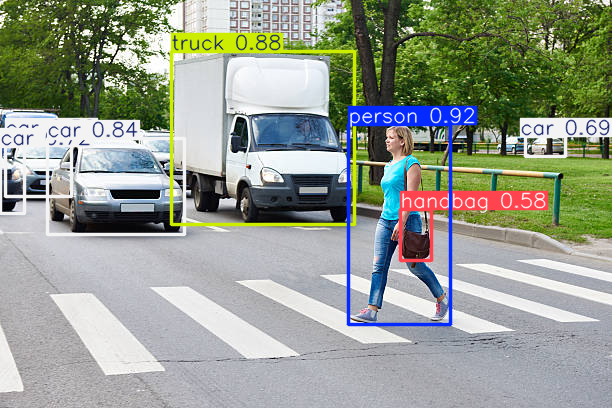

In [4]:
!pip install ultralytics

from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load pretrained YOLOv8 Nano model
model = YOLO('yolov8n.pt')

# Run detection on image
results = model('/content/sample_data/istockphoto-478525372-612x612.jpg', conf=0.5)

# Process detection results
for result in results:
    boxes = result.boxes

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]

        print(f'{cls_name}: {conf:.2f} at [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]')

# Show image with bounding boxes
annotated = results[0].plot()
cv2_imshow(annotated)